## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.0016; nt=2500

ntr=100

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

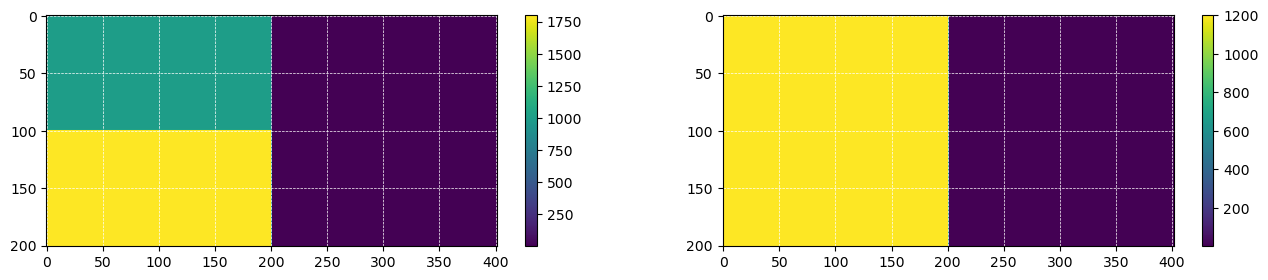

In [50]:
# True
!makevel nz=100 nx=$nx v000=1000 > c1
!makevel nz=101 nx=$nx v000=1800 > c2
!makevel nz=$nz nx=$nx v000=1 > rho #otherwise underflow when computing the gradient
!cat c1 c2 > tmp && transp < tmp n1=$nx > vp
!cat vp rho > true
!rm c1 c2 tmp

!makevel nz=1   nx=$nx v000=100  > topo

# Background
!makevel nz=$nz nx=$nx v000=1200 > vp
!cat vp rho > init

#plot
plt.figure(figsize=(16,3))
true=read('true',(2*nx,nz))
init=read('init',(2*nx,nz))
plt.subplot(1,2,1); imshow(true)
plt.subplot(1,2,2); imshow(init)

In [3]:
!cat setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '10 10 1'
FILE_MODEL              true
MODEL_ATTRIBUTES        vp #'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '40 500 500'
FR                      '40 10  0'
DR                      '0  20 0'
NR                      100

SCOMP                   vz
RCOMP                   vz #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           2000
DT           0.002
FPEAK        7

## for PFEI ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vp:1000:1800'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'


#SNAPSHOT     vz
#NSNAPSHOT    50

IF_USE_CHECKPOINT   F
RCOMP       px


In [4]:
vp=init
vs=vp/np.sqrt(3)
rho=1000.
def gvp(glda):     return  glda            *2*rho*vp
def gvs(glda,gmu): return (glda*(-2) + gmu)*2*rho*vs

## PSV2ndordUE

### uz-uz

#### Obs & Syn data

In [54]:
!cp setup_default setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:41:54
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

In [55]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:41:57
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

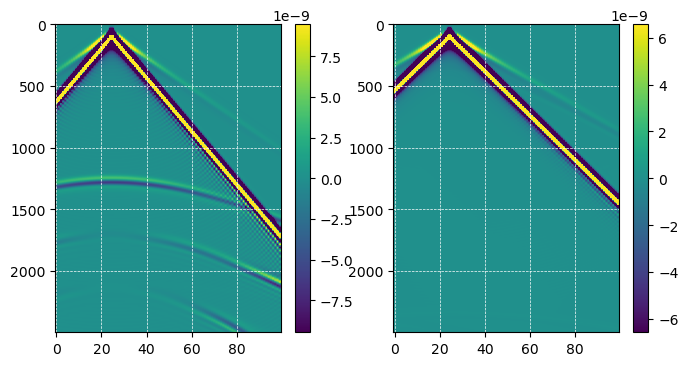

In [56]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=95)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=95)

#### Gradient

In [57]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 48 Sep 12 17:40 ../../exe/GradientTest -> gradienttest_PSV2ndUE_FDSG_O4_velocities-density
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:42:05
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) 

 it----        2000
 fld_a minmax values:  -3.16066850E-15   3.52487298E-15
 fld_u minmax values:  -1.58722049E-08   1.80332247E-08
 it----        1500
 fld_a minmax values:  -3.72564630E-14   8.79596756E-14
 fld_u minmax values:  -2.70665943E-08   3.79784417E-08
 it----        1000
 fld_a minmax values:  -1.64961550E-13   9.68109056E-14
 fld_u minmax values:  -2.73363145E-08   5.02843385E-08
 it----         500
 fld_a minmax values:  -3.32109719E-13   1.76492135E-13
 fld_u minmax values:  -6.20786977E-08   8.25636377E-08
 Elapsed time to evolve field           3.65138054E-02
 Elapsed time to load boundary         0.475898266    
 Elapsed time to update field           1.45668983E-02
 Elapsed time to rm source              1.09720230E-02
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       3.18908691E-03
 Elapsed time to update adj field            2.56338120E-02
 Elapsed time to evolve adj field            4.48846817E-03
 Elapsed time to extract fields   

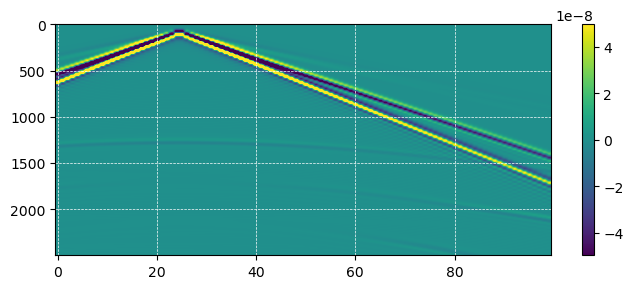

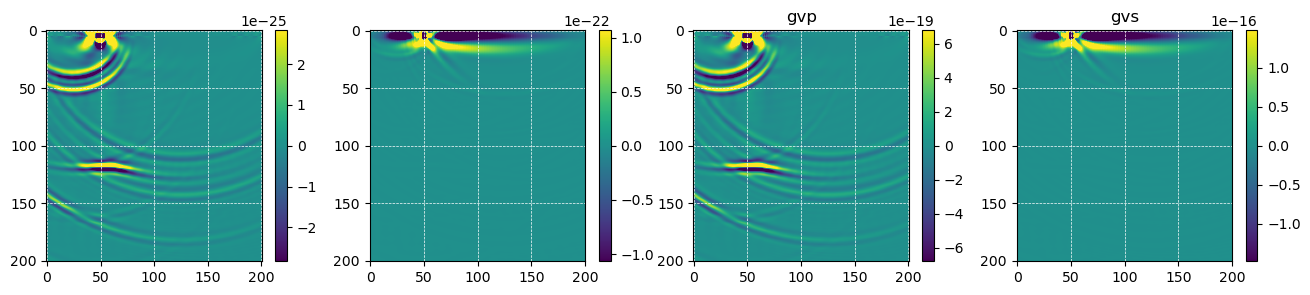

In [58]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

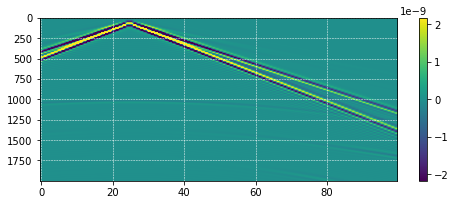

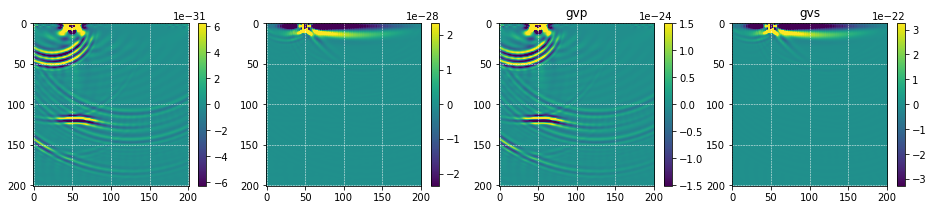

In [9]:
# ## OLD fig using m_propagator_DAS
# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# # plt.figure(figsize=(8,3))
# # plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# # plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [61]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-4 1e-3 1e-2 1e-1 1 1e1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-05   1231.43481       1231.43481       0.00000000     -0.338984460            -Infinity T
 1st cond   1.00000005E-03   1231.43481       1231.43481       0.00000000     -0.338984460            -Infinity T
 1st cond   9.99999978E-03   1231.43127       1231.43481     -0.354003906     -0.338984460      0.957572639     T
 1st cond  0.100000001       1231.39685       1231.43481     -0.379638672     -0.338984460      0.892913401     T
 1st cond   1.00000000       1231.10486       1231.43481     -0.329956055     -0.338984460       1.02736247     T
 1st cond   10.0000000       1229.09497       1231.43481     -0.233984381     -0.338984460       1.44874823     T


In [60]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   1231.43506       1231.43481      -24.4140625     -0.338984460       1.38848033E-02 F
 1st cond  -9.99999975E-05   1231.43506       1231.43481      -2.44140625     -0.338984460      0.138848037     F
 1st cond  -1.00000005E-03   1231.43506       1231.43481     -0.244140610     -0.338984460       1.38848042     F
 1st cond  -9.99999978E-03   1231.43640       1231.43481     -0.158691406     -0.338984460       2.13612366     F
 1st cond -0.100000001       1231.46497       1231.43481     -0.301513672     -0.338984460       1.12427557     F
 1st cond  -1.00000000       1231.77673       1231.43481     -0.341918945     -0.338984460      0.991417587     F


##### seems that gvp is not so good..

#### gradienttest on gvs

In [62]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '1e-4 1e-3 1e-2 1e-1 1 1e1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-05   70.1728058       70.1733551      -5.49316406      -5.44160938      0.990614772     T
 1st cond   1.00000005E-03   70.1680298       70.1733551      -5.32531691      -5.44160938       1.02183771     T
 1st cond   9.99999978E-03   70.1206436       70.1733551      -5.27114868      -5.44160938       1.03233838     T
 1st cond  0.100000001       69.6510391       70.1733551      -5.22315979      -5.44160938       1.04182327     T
 1st cond   1.00000000       65.7297592       70.1733551      -4.44359589      -5.44160938       1.22459590     T
 1st cond   10.0000000       61.7771225       70.1733551     -0.839623272      -5.44160938       6.48101282     T


In [63]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   70.1734085       70.1733551      -5.34057617      -5.44160938       1.01891804     F
 1st cond  -9.99999975E-05   70.1739197       70.1733551      -5.64575195      -5.44160938      0.963841379     F
 1st cond  -1.00000005E-03   70.1787033       70.1733551      -5.34820509      -5.44160938       1.01746464     F
 1st cond  -9.99999978E-03   70.2260208       70.1733551      -5.26657104      -5.44160938       1.03323579     F
 1st cond -0.100000001       70.7035980       70.1733551      -5.30242920      -5.44160938       1.02624834     F
 1st cond  -1.00000000       75.1797485       70.1733551      -5.00639343      -5.44160938       1.08693206     F


### uz-ux

#### Obs & Syn data

In [64]:
!cp setup_default setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:50:20
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

In [65]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:50:26
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

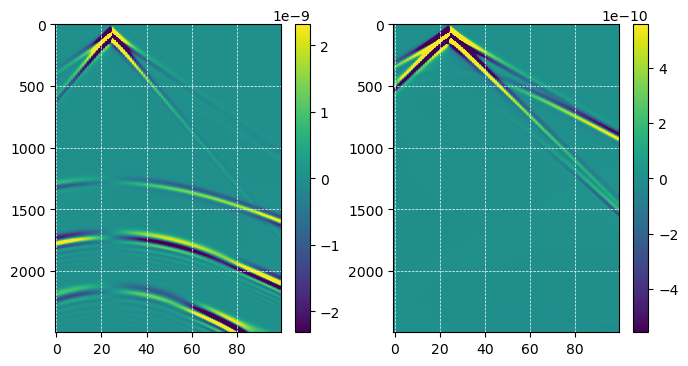

In [66]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [67]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 48 Sep 12 17:46 ../../exe/GradientTest -> gradienttest_PSV2ndUE_FDSG_O4_velocities-density
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:50:36
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) 

 it----        1500
 fld_a minmax values:  -2.94813671E-15   2.55162153E-15
 fld_u minmax values:  -2.70665943E-08   3.79784417E-08
 it----        1000
 fld_a minmax values:  -2.76778370E-15   2.25643860E-15
 fld_u minmax values:  -2.73363145E-08   5.02843385E-08
 it----         500
 fld_a minmax values:  -2.43980979E-15   2.07145761E-15
 fld_u minmax values:  -6.20786977E-08   8.25636377E-08
 Elapsed time to evolve field           3.36771011E-02
 Elapsed time to load boundary         0.473540306    
 Elapsed time to update field           1.63459778E-02
 Elapsed time to rm source              1.09977722E-02
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       2.68030167E-03
 Elapsed time to update adj field            1.93219185E-02
 Elapsed time to evolve adj field            4.88090515E-03
 Elapsed time to extract fields              0.00000000    
 Elapsed time to compute Poynting vectors    3.16715240E-03
 Elapsed time to correlate                   1

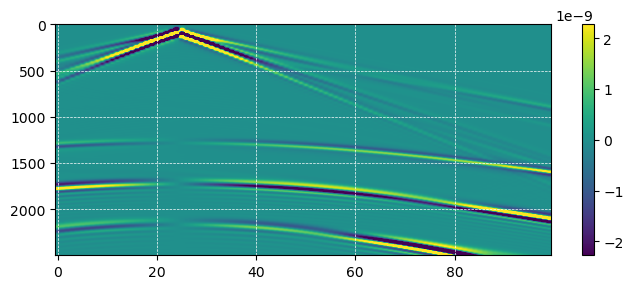

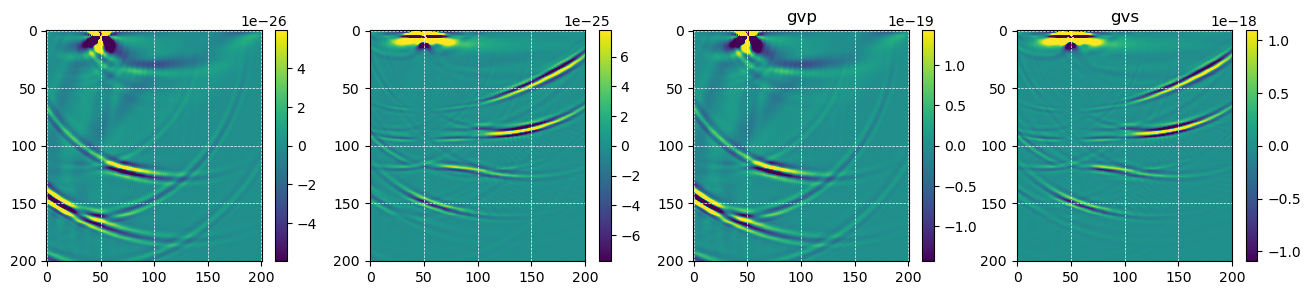

In [68]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

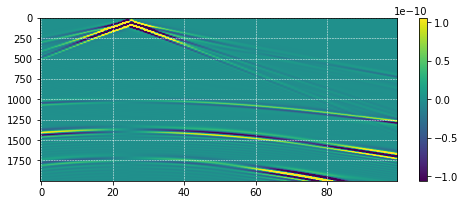

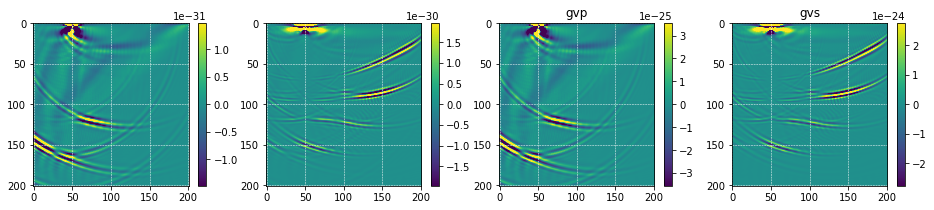

In [18]:
# ## OLD fig using m_propagator_DAS

# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [69]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   16.0819492       16.0819778      -2.86102295     -0.434776634      0.151965454     T
 1st cond   9.99999975E-05   16.0819168       16.0819778     -0.610351562     -0.434776634      0.712338030     T
 1st cond   1.00000005E-03   16.0815296       16.0819778     -0.448226899     -0.434776634      0.969992280     T
 1st cond   9.99999978E-03   16.0777454       16.0819778     -0.423240662     -0.434776634       1.02725625     T
 1st cond  0.100000001       16.0398750       16.0819778     -0.421028137     -0.434776634       1.03265452     T
 1st cond   1.00000000       15.6881933       16.0819778     -0.393784523     -0.434776634       1.10409784     T


In [70]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   16.0819626       16.0819778       1.52587891     -0.434776634     -0.284935206     T
 1st cond  -9.99999975E-05   16.0819817       16.0819778      -3.81469727E-02 -0.434776634       11.3974085     F
 1st cond  -1.00000005E-03   16.0823669       16.0819778     -0.389099091     -0.434776634       1.11739314     F
 1st cond  -9.99999978E-03   16.0860500       16.0819778     -0.407218933     -0.434776634       1.06767297     F
 1st cond -0.100000001       16.1232567       16.0819778     -0.412788391     -0.434776634       1.05326760     F
 1st cond  -1.00000000       16.5187950       16.0819778     -0.436817169     -0.434776634      0.995328605     F


#### gradienttest on gvs

In [71]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   8.35534191       8.35535431      -1.23977661      -1.07551193      0.867504597     T
 1st cond   9.99999975E-05   8.35523415       8.35535431      -1.20162964      -1.07551193      0.895044446     T
 1st cond   1.00000005E-03   8.35430050       8.35535431      -1.05381012      -1.07551193       1.02059364     T
 1st cond   9.99999978E-03   8.34484291       8.35535431      -1.05113983      -1.07551193       1.02318633     T
 1st cond  0.100000001       8.25284767       8.35535431      -1.02506638      -1.07551193       1.04921198     T
 1st cond   1.00000000       7.58760977       8.35535431     -0.767744541      -1.07551193       1.40087211     T


In [72]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   8.35536289       8.35535431     -0.858306885      -1.07551193       1.25306225     F
 1st cond  -9.99999975E-05   8.35542870       8.35535431     -0.743865967      -1.07551193       1.44584107     F
 1st cond  -1.00000005E-03   8.35640621       8.35535431      -1.05190277      -1.07551193       1.02244425     F
 1st cond  -9.99999978E-03   8.36593151       8.35535431      -1.05772018      -1.07551193       1.01682079     F
 1st cond -0.100000001       8.46336746       8.35535431      -1.08013153      -1.07551193      0.995723128     F
 1st cond  -1.00000000       9.68407917       8.35535431      -1.32872486      -1.07551193      0.809431612     F


### uz-ez

#### Obs & Syn data

In [73]:
!cp setup_default setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:57:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

In [74]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:57:37
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

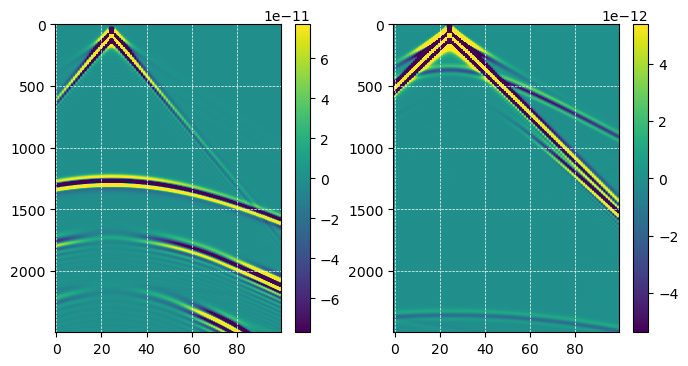

In [75]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=95)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=95)

#### Gradient

In [76]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 48 Sep 12 17:46 ../../exe/GradientTest -> gradienttest_PSV2ndUE_FDSG_O4_velocities-density
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 17:57:46
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) 

 it----        1500
 fld_a minmax values:  -5.39633110E-18   3.60357181E-18
 fld_u minmax values:  -2.70665943E-08   3.79784417E-08
 it----        1000
 fld_a minmax values:  -5.96814658E-18   4.52002837E-18
 fld_u minmax values:  -2.73363145E-08   5.02843385E-08
 it----         500
 fld_a minmax values:  -1.29657517E-17   8.18742460E-18
 fld_u minmax values:  -6.20786977E-08   8.25636377E-08
 Elapsed time to evolve field           3.06234360E-02
 Elapsed time to load boundary         0.472446918    
 Elapsed time to update field           2.23984718E-02
 Elapsed time to rm source              8.26263428E-03
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       3.18336487E-03
 Elapsed time to update adj field            1.41391754E-02
 Elapsed time to evolve adj field            6.00814819E-03
 Elapsed time to extract fields              0.00000000    
 Elapsed time to compute Poynting vectors    2.37464905E-03
 Elapsed time to correlate                   1

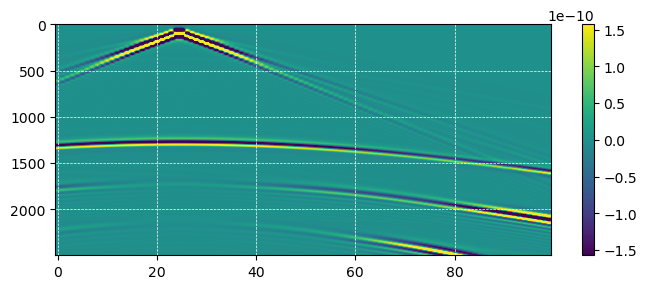

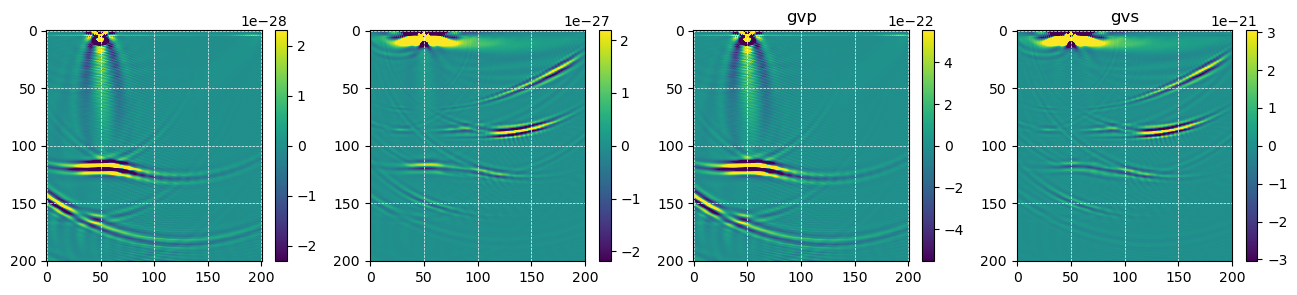

In [77]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

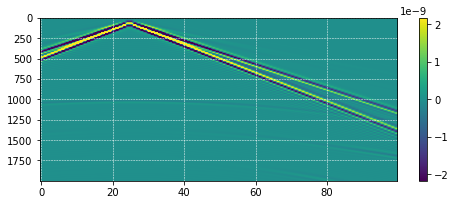

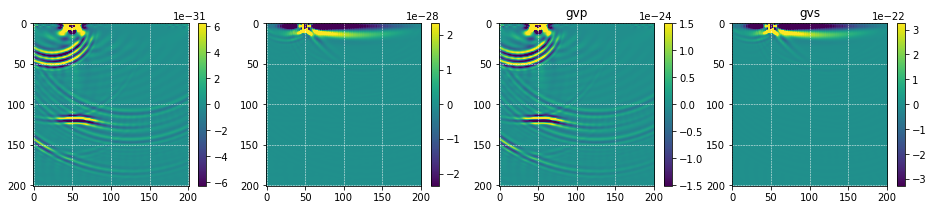

In [9]:
# ## OLD fig using m_propagator_DAS
# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# # plt.figure(figsize=(8,3))
# # plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# # plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [78]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   24.1948795       24.1949444      -6.48498535     -0.729864120      0.112546764     T
 1st cond   9.99999975E-05   24.1948795       24.1949444     -0.648498535     -0.729864120       1.12546766     T
 1st cond   1.00000005E-03   24.1941853       24.1949444     -0.759124696     -0.729864120      0.961454868     T
 1st cond   9.99999978E-03   24.1877670       24.1949444     -0.717735291     -0.729864120       1.01689875     T
 1st cond  0.100000001       24.1242485       24.1949444     -0.706958771     -0.729864120       1.03239989     T
 1st cond   1.00000000       23.5270157       24.1949444     -0.667928696     -0.729864120       1.09272754     T


In [79]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   24.1949310       24.1949444       1.33514404     -0.729864120     -0.546655715     T
 1st cond  -9.99999975E-05   24.1949730       24.1949444     -0.286102295     -0.729864120       2.55105996     F
 1st cond  -1.00000005E-03   24.1955891       24.1949444     -0.644683778     -0.729864120       1.13212729     F
 1st cond  -9.99999978E-03   24.2019672       24.1949444     -0.702285767     -0.729864120       1.03926945     F
 1st cond -0.100000001       24.2661037       24.1949444     -0.711593628     -0.729864120       1.02567542     F
 1st cond  -1.00000000       24.9426689       24.1949444     -0.747724533     -0.729864120      0.976113617     F


##### seems that gvp is not so good..

#### gradienttest on gvs

In [80]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   18.0575695       18.0576000      -3.05175781      -1.09297729      0.358146787     T
 1st cond   9.99999975E-05   18.0574799       18.0576000      -1.20162964      -1.09297729      0.909579158     T
 1st cond   1.00000005E-03   18.0564651       18.0576000      -1.13487244      -1.09297729      0.963083804     T
 1st cond   9.99999978E-03   18.0471172       18.0576000      -1.04827881      -1.09297729       1.04263985     T
 1st cond  0.100000001       17.9550114       18.0576000      -1.02588654      -1.09297729       1.06539786     T
 1st cond   1.00000000       17.1899586       18.0576000     -0.867641449      -1.09297729       1.25971079     T


In [81]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ez' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   18.0576038       18.0576000     -0.381469727      -1.09297729       2.86517429     F
 1st cond  -9.99999975E-05   18.0577164       18.0576000      -1.16348267      -1.09297729      0.939401448     F
 1st cond  -1.00000005E-03   18.0585938       18.0576000     -0.993728578      -1.09297729       1.09987509     F
 1st cond  -9.99999978E-03   18.0681114       18.0576000      -1.05113983      -1.09297729       1.03980196     F
 1st cond -0.100000001       18.1635818       18.0576000      -1.05981827      -1.09297729       1.03128743     F
 1st cond  -1.00000000       19.2674885       18.0576000      -1.20988846      -1.09297729      0.903370261     F


### uz-ex

#### Obs & Syn data

In [82]:
!cp setup_default setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 18:07:19
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

In [83]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2ndUE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 680480 Sep 12 17:39 ../../exe/fwd_PSV2ndUE_FDSG_O4_
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 18:07:22
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

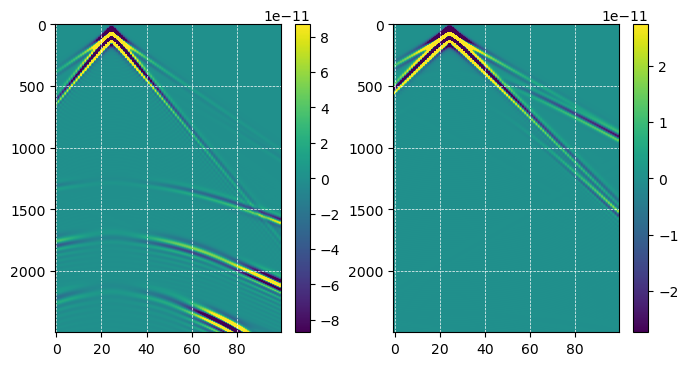

In [85]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [86]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux ez ex es'" >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 48 Sep 12 17:46 ../../exe/GradientTest -> gradienttest_PSV2ndUE_FDSG_O4_velocities-density
 Git Commit: 9e96c18
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 18:07:42
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) 

 it----        2000
 fld_a minmax values:  -3.74420409E-18   3.70612607E-18
 fld_u minmax values:  -1.58722049E-08   1.80332247E-08
 it----        1500
 fld_a minmax values:  -2.83290045E-18   3.08720555E-18
 fld_u minmax values:  -2.70665943E-08   3.79784417E-08
 it----        1000
 fld_a minmax values:  -2.35222787E-18   2.54370343E-18
 fld_u minmax values:  -2.73363145E-08   5.02843385E-08
 it----         500
 fld_a minmax values:  -2.08053605E-18   2.23379318E-18
 fld_u minmax values:  -6.20786977E-08   8.25636377E-08
 Elapsed time to evolve field           4.22382355E-02
 Elapsed time to load boundary         0.464018345    
 Elapsed time to update field           2.03714371E-02
 Elapsed time to rm source              7.60459900E-03
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       3.25584412E-03
 Elapsed time to update adj field            9.90009308E-03
 Elapsed time to evolve adj field            6.00910187E-03
 Elapsed time to extract fields   

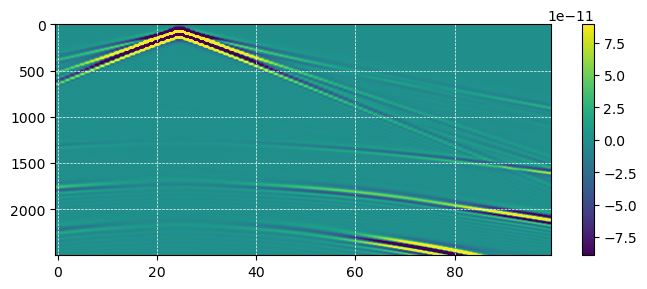

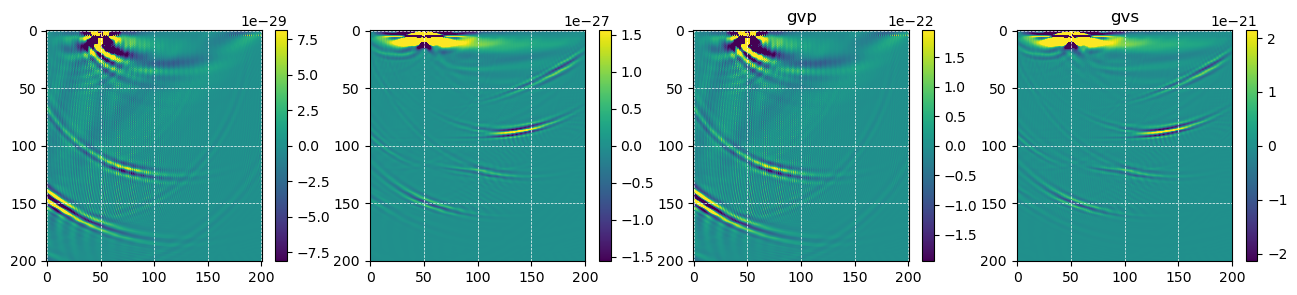

In [87]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

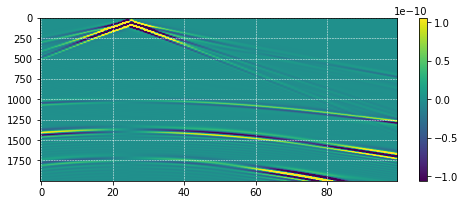

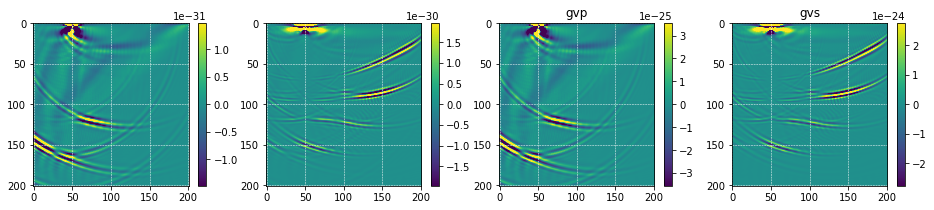

In [18]:
# ## OLD fig using m_propagator_DAS

# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [88]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   44.7827415       44.7828331      -9.15527344     -0.282506853       3.08572818E-02 T
 1st cond   9.99999975E-05   44.7828026       44.7828331     -0.305175781     -0.282506853      0.925718486     T
 1st cond   1.00000005E-03   44.7825279       44.7828331     -0.305175781     -0.282506853      0.925718486     T
 1st cond   9.99999978E-03   44.7803726       44.7828331     -0.246047974     -0.282506853       1.14817798     T
 1st cond  0.100000001       44.7597466       44.7828331     -0.230865479     -0.282506853       1.22368598     T
 1st cond   1.00000000       44.5840187       44.7828331     -0.198814392     -0.282506853       1.42095780     T


In [89]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   44.7828331       44.7828331      -0.00000000     -0.282506853             Infinity T
 1st cond  -9.99999975E-05   44.7828026       44.7828331      0.305175781     -0.282506853     -0.925718486     T
 1st cond  -1.00000005E-03   44.7829781       44.7828331     -0.144958496     -0.282506853       1.94888091     F
 1st cond  -9.99999978E-03   44.7846489       44.7828331     -0.181579590     -0.282506853       1.55582929     F
 1st cond -0.100000001       44.8046761       44.7828331     -0.218429565     -0.282506853       1.29335451     F
 1st cond  -1.00000000       45.0271378       44.7828331     -0.244304657     -0.282506853       1.15637112     F


##### gvp is not so good..

#### gradienttest on gvs

In [90]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   23.6775723       23.6776123      -4.00543213      -1.43513906      0.358298182     T
 1st cond   9.99999975E-05   23.6774292       23.6776123      -1.83105469      -1.43513906      0.783777297     T
 1st cond   1.00000005E-03   23.6760712       23.6776123      -1.54113758      -1.43513906      0.931220591     T
 1st cond   9.99999978E-03   23.6631241       23.6776123      -1.44882202      -1.43513906      0.990555823     T
 1st cond  0.100000001       23.5385017       23.6776123      -1.39110565      -1.43513906       1.03165352     T
 1st cond   1.00000000       22.6414776       23.6776123      -1.03613472      -1.43513906       1.38508928     T


In [91]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "MODEL_ATTRIBUTES    'vp rho'" >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ex' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   23.6775532       23.6776123       5.91278076      -1.43513906     -0.242718130     T
 1st cond  -9.99999975E-05   23.6777096       23.6776123     -0.972747803      -1.43513906       1.47534549     F
 1st cond  -1.00000005E-03   23.6789436       23.6776123      -1.33132923      -1.43513906       1.07797456     F
 1st cond  -9.99999978E-03   23.6918259       23.6776123      -1.42135620      -1.43513906       1.00969696     F
 1st cond -0.100000001       23.8245144       23.6776123      -1.46902084      -1.43513906      0.976935804     F
 1st cond  -1.00000000       25.4961071       23.6776123      -1.81849480      -1.43513906      0.789190650     F
